# Option 1: Stock Price Trend Prediction - Classification

## Objective
Predict whether stock price will rise (1) or fall (0) based on technical indicators

## Models Tested
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn kagglehub xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, confusion_matrix, roc_curve, auc, classification_report)
import kagglehub, os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ All libraries loaded successfully")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✓ All libraries loaded successfully


c:\Users\25012923g\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Data Loading & Exploration

In [2]:
# Download S&P 500 dataset
path = kagglehub.dataset_download("camnugent/sandp500")
files = os.listdir(path)
csv_file = [f for f in files if f.endswith(".csv")][0]
data = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset Shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nDate Range: {data['date'].min()} to {data['date'].max()}")
print(f"\nUnique Stocks: {data['Name'].nunique()}")
print(f"\nFirst 5 rows:")
print(data.head())
print(f"\nMissing values:")
print(data.isnull().sum())

Dataset Shape: (619040, 7)

Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

Date Range: 2013-02-08 to 2018-02-07

Unique Stocks: 505

First 5 rows:
         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL

Missing values:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64


## Step 2: Feature Engineering

In [3]:
# Select top 5 stocks
top_stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
data_filtered = data[data['Name'].isin(top_stocks)].copy()
data_filtered = data_filtered.sort_values(['Name', 'date']).reset_index(drop=True)

def create_classification_features(stock_data):
    """Create comprehensive features for price trend classification"""
    stock_data = stock_data.sort_values('date').reset_index(drop=True)
    
    # Target: 1 if tomorrow price > today, else 0
    stock_data['price_change'] = stock_data['close'].diff()
    stock_data['target'] = (stock_data['price_change'] > 0).astype(int).shift(-1)
    
    # Daily Returns
    stock_data['daily_return'] = stock_data['close'].pct_change()
    stock_data['return_abs'] = abs(stock_data['daily_return'])
    
    # Price Range Metrics
    stock_data['price_range'] = (stock_data['high'] - stock_data['low']) / stock_data['open']
    stock_data['close_open_ratio'] = (stock_data['close'] - stock_data['open']) / stock_data['open']
    
    # Volume Metrics
    stock_data['volume_change'] = stock_data['volume'].pct_change()
    stock_data['volume_ma_ratio'] = stock_data['volume'] / stock_data['volume'].rolling(20).mean()
    
    # Moving Averages
    stock_data['MA_5'] = stock_data['close'].rolling(window=5).mean()
    stock_data['MA_20'] = stock_data['close'].rolling(window=20).mean()
    stock_data['MA_50'] = stock_data['close'].rolling(window=50).mean()
    stock_data['MA_ratio_5_20'] = stock_data['MA_5'] / stock_data['MA_20']
    stock_data['MA_ratio_20_50'] = stock_data['MA_20'] / stock_data['MA_50']
    
    # RSI (Relative Strength Index)
    delta = stock_data['daily_return'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    stock_data['rsi'] = 100 - (100 / (1 + rs))
    
    # Volatility (Standard Deviation)
    stock_data['volatility'] = stock_data['daily_return'].rolling(window=20).std()
    stock_data['volatility_ratio'] = stock_data['volatility'] / stock_data['daily_return'].rolling(60).std()
    
    # MACD-like indicator
    ema_12 = stock_data['close'].ewm(span=12).mean()
    ema_26 = stock_data['close'].ewm(span=26).mean()
    stock_data['macd_line'] = (ema_12 - ema_26) / ema_26
    
    # Bollinger Bands
    bb_ma = stock_data['close'].rolling(20).mean()
    bb_std = stock_data['close'].rolling(20).std()
    stock_data['bb_upper'] = (bb_ma + 2*bb_std - stock_data['close']) / (4*bb_std)
    stock_data['bb_lower'] = (stock_data['close'] - (bb_ma - 2*bb_std)) / (4*bb_std)
    
    return stock_data

# Apply feature engineering
data_features = pd.concat([create_classification_features(data_filtered[data_filtered['Name'] == stock]) 
                            for stock in top_stocks], ignore_index=True)
data_features = data_features.dropna()

print(f"✓ Features created. Dataset shape: {data_features.shape}")
print(f"\nTarget distribution:")
print(data_features['target'].value_counts())
print(f"\nTarget ratio: {data_features['target'].sum() / len(data_features):.2%} UP days")

✓ Features created. Dataset shape: (4792, 26)

Target distribution:
target
1.0    2518
0.0    2274
Name: count, dtype: int64

Target ratio: 52.55% UP days


## Step 3: Data Visualization

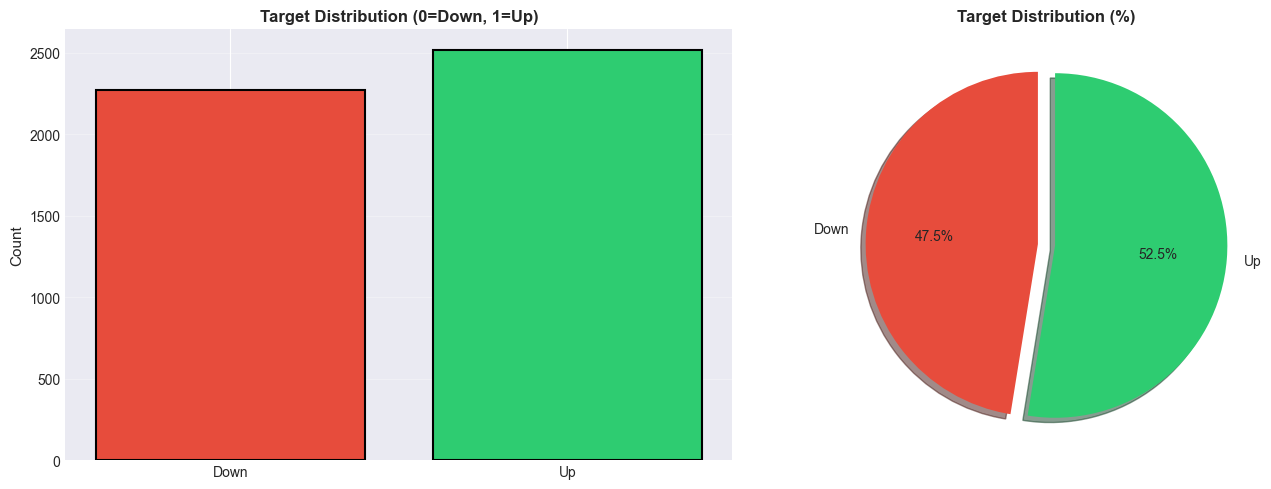

✓ Saved: 01_target_distribution.png


In [4]:
# Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = data_features['target'].value_counts().sort_index()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Down', 'Up'], target_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Target Distribution (0=Down, 1=Up)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(target_counts.values, labels=['Down', 'Up'], autopct='%1.1f%%', colors=colors,
            explode=(0.05, 0.05), shadow=True, startangle=90)
axes[1].set_title('Target Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 01_target_distribution.png")

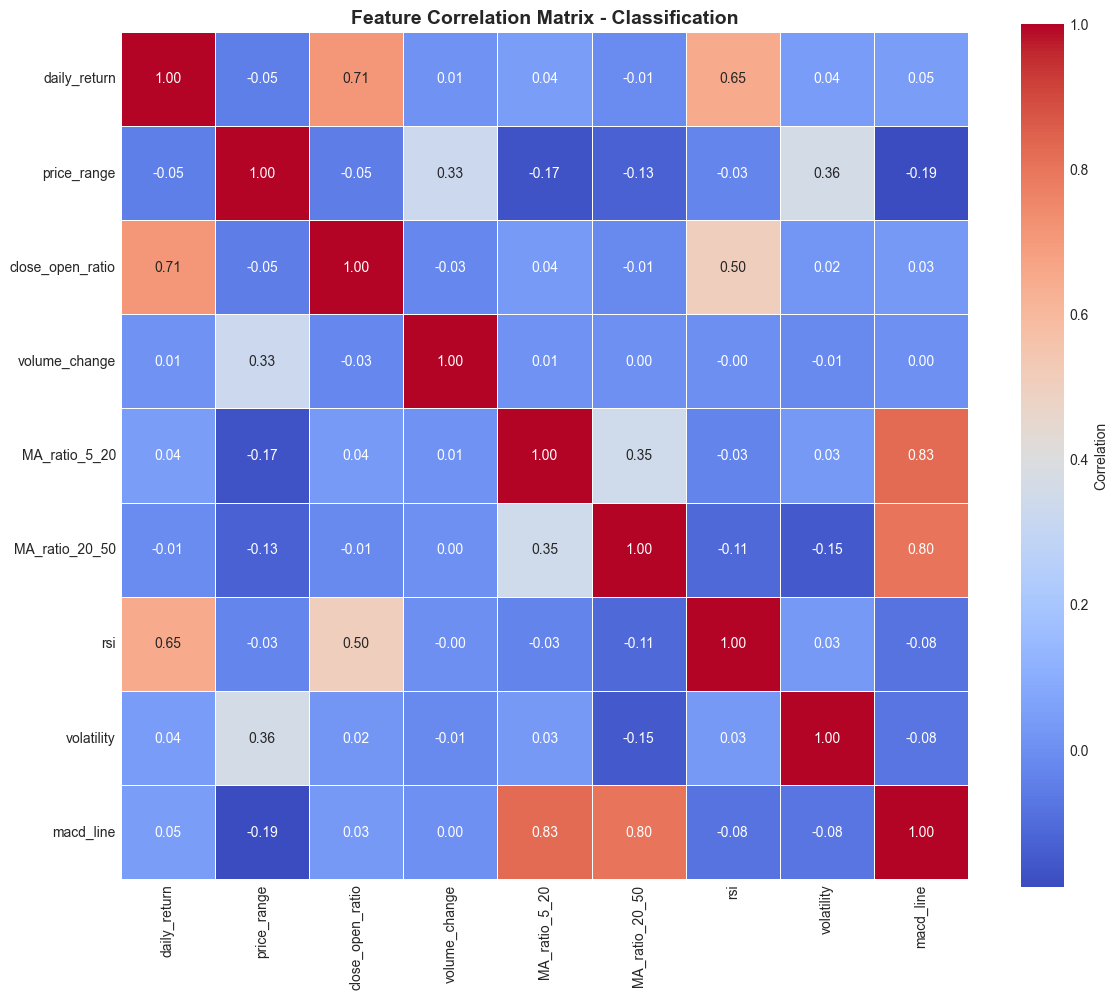

✓ Saved: 02_feature_correlation.png


In [5]:
# Feature Correlation Matrix
feature_cols = ['daily_return', 'price_range', 'close_open_ratio', 'volume_change',
                'MA_ratio_5_20', 'MA_ratio_20_50', 'rsi', 'volatility', 'macd_line']

plt.figure(figsize=(12, 10))
corr_matrix = data_features[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            cbar_kws={'label': 'Correlation'}, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix - Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 02_feature_correlation.png")

## Step 4: Data Preparation

In [6]:
# Prepare data
X = data_features[feature_cols].copy()
y = data_features['target'].copy()
X = X.fillna(X.mean())

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")
print(f"Class distribution (Train): Up={y_train.sum()}, Down={(1-y_train).sum()}")
print(f"Class distribution (Test):  Up={y_test.sum()}, Down={(1-y_test).sum()}")
print(f"\nFeatures shape: {X_train.shape}")

Training set: 3833 samples | Test set: 959 samples
Class distribution (Train): Up=2014.0, Down=1819.0
Class distribution (Test):  Up=504.0, Down=455.0

Features shape: (3833, 9)


## Step 5: Model Training

In [7]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, 
                                           n_jobs=-1, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'conf_matrix': confusion_matrix(y_test, y_pred)
    }
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if roc_auc:
        print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"CV Score:  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\n✓ All models trained successfully!")


Training Logistic Regression...
Accuracy:  0.4974
Precision: 0.5236
Recall:    0.4841
F1-Score:  0.5031
ROC-AUC:   0.5069
CV Score:  0.5213 (+/- 0.0182)

Training Decision Tree...
Accuracy:  0.5068
Precision: 0.5287
Recall:    0.5675
F1-Score:  0.5474
ROC-AUC:   0.5056
CV Score:  0.5043 (+/- 0.0106)

Training Random Forest...
Accuracy:  0.5089
Precision: 0.5306
Recall:    0.5675
F1-Score:  0.5484
ROC-AUC:   0.5140
CV Score:  0.5293 (+/- 0.0154)

Training SVM...
Accuracy:  0.5057
Precision: 0.5284
Recall:    0.5536
F1-Score:  0.5407
ROC-AUC:   0.5082
CV Score:  0.5275 (+/- 0.0129)

✓ All models trained successfully!


## Step 6: Performance Comparison


MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.4974     0.5236  0.4841    0.5031   0.5069
Decision Tree          0.5068     0.5287  0.5675    0.5474   0.5056
Random Forest          0.5089     0.5306  0.5675    0.5484   0.5140
SVM                    0.5057     0.5284  0.5536    0.5407   0.5082


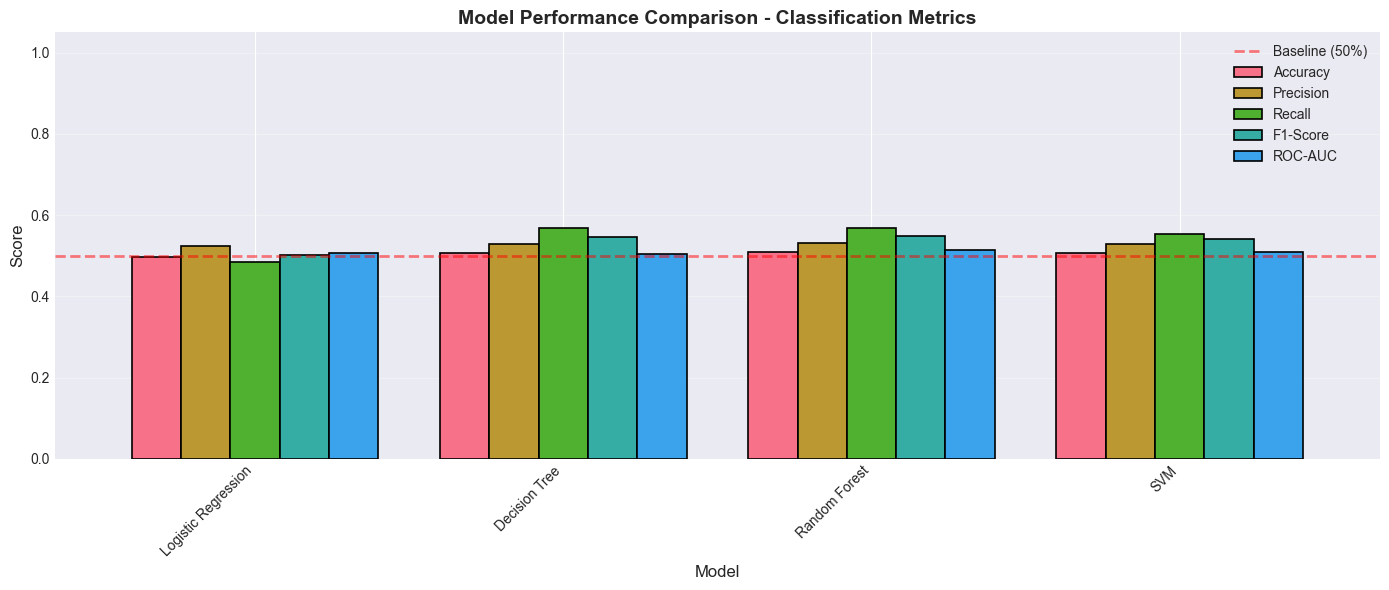


✓ Saved: 03_model_comparison.png


In [8]:
# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Accuracy': [results[name]['accuracy'] for name in models.keys()],
    'Precision': [results[name]['precision'] for name in models.keys()],
    'Recall': [results[name]['recall'] for name in models.keys()],
    'F1-Score': [results[name]['f1'] for name in models.keys()],
    'ROC-AUC': [results[name]['roc_auc'] if results[name]['roc_auc'] else 0 for name in models.keys()]
}, index=models.keys())

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(metrics_df.round(4))

# Visualization: Metrics Comparison
fig, ax = plt.subplots(figsize=(14, 6))
metrics_df.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=1.2)
ax.set_title('Model Performance Comparison - Classification Metrics', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim([0, 1.05])
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Baseline (50%)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('03_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 03_model_comparison.png")

## Step 7: Confusion Matrices

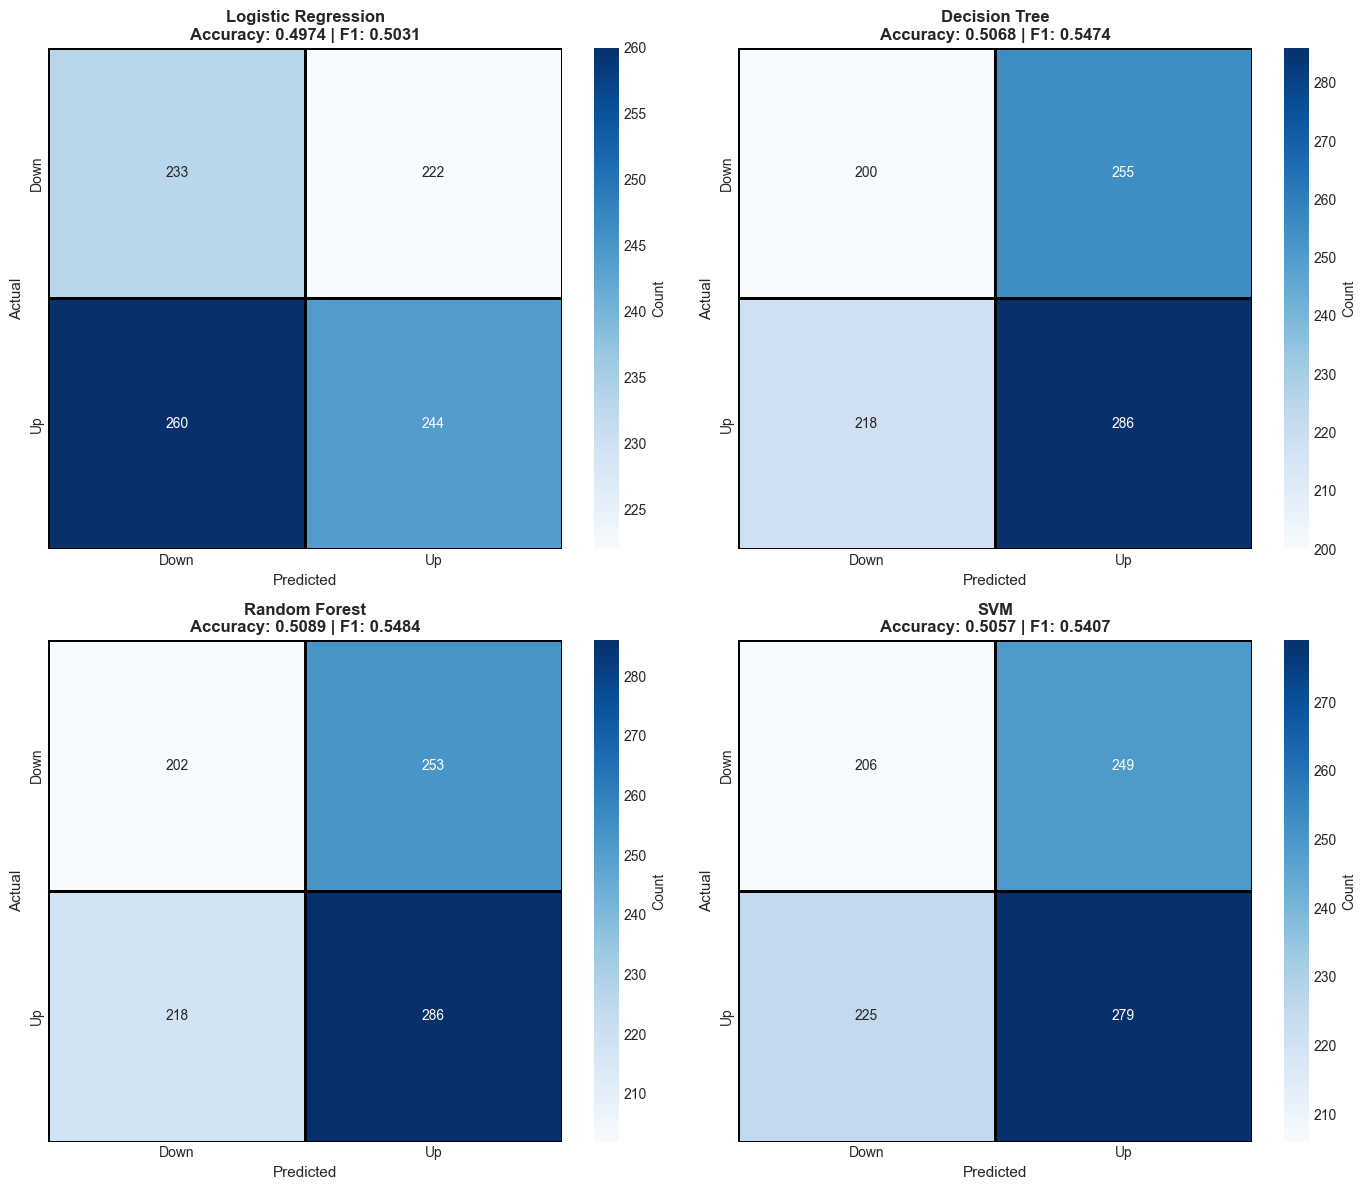

✓ Saved: 04_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, model_result) in enumerate(results.items()):
    cm = model_result['conf_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'],
                cbar_kws={'label': 'Count'}, linewidths=1, linecolor='black')
    axes[idx].set_title(f"{name}\nAccuracy: {model_result['accuracy']:.4f} | F1: {model_result['f1']:.4f}", 
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.savefig('04_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 04_confusion_matrices.png")

## Step 8: ROC Curves

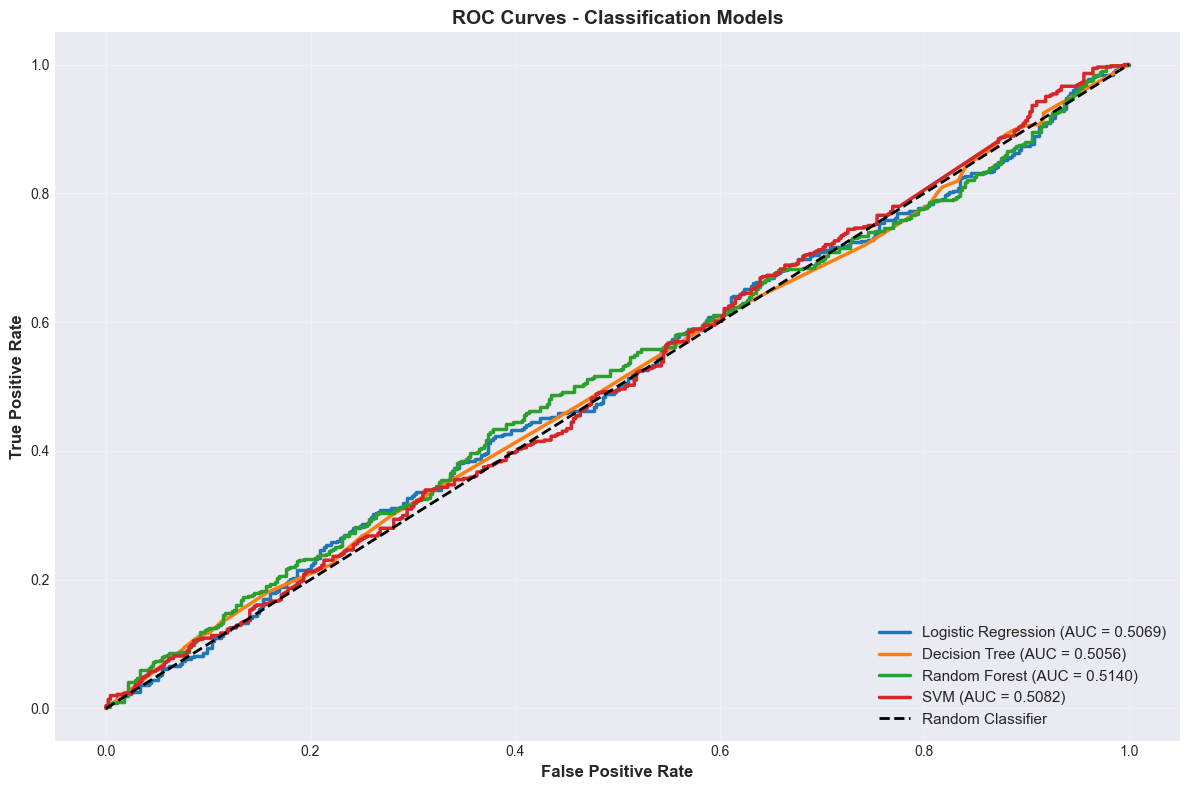

✓ Saved: 05_roc_curves.png


In [10]:
plt.figure(figsize=(12, 8))

colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for idx, (name, model_result) in enumerate(results.items()):
    if model_result['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, model_result['y_pred_proba'])
        roc_auc = model_result['roc_auc']
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})", linewidth=2.5, color=colors_list[idx])

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Classification Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('05_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 05_roc_curves.png")

## Step 9: Feature Importance

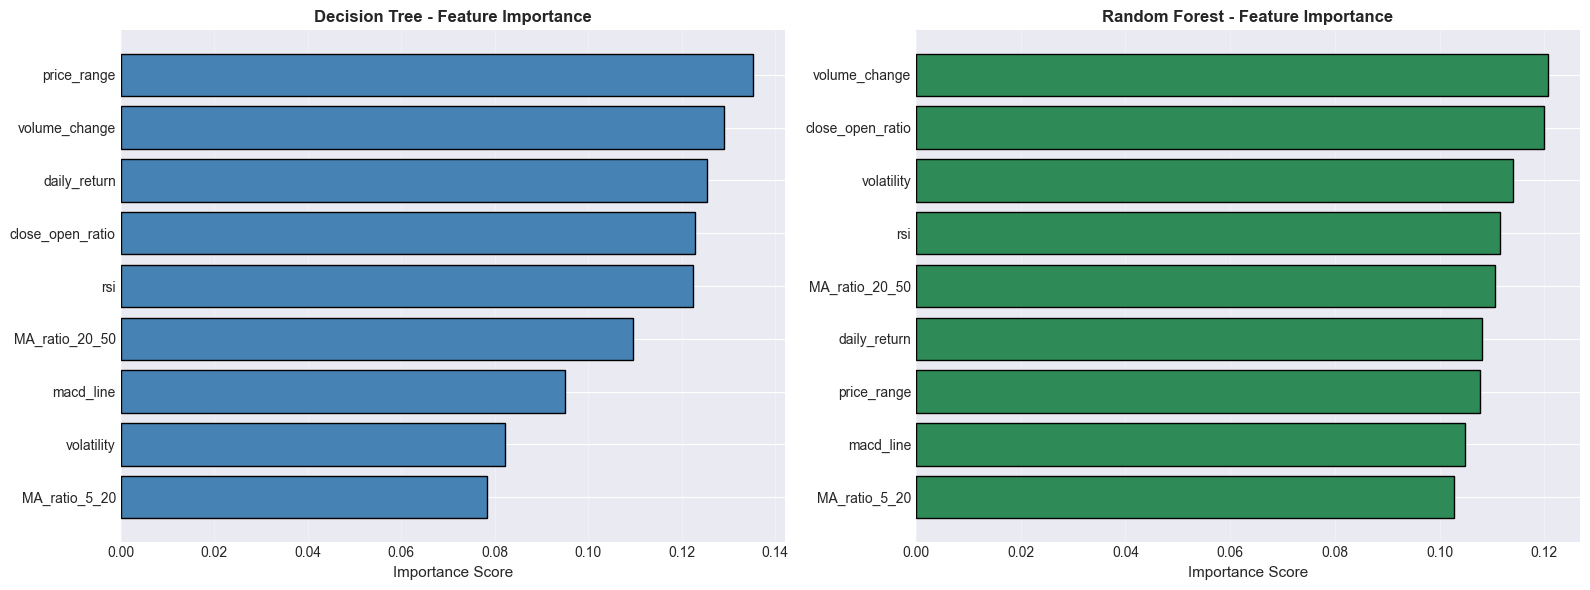

✓ Saved: 06_feature_importance.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decision Tree
dt_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': results['Decision Tree']['model'].feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(dt_importance['feature'], dt_importance['importance'], color='steelblue', edgecolor='black')
axes[0].set_title('Decision Tree - Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# Random Forest
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': results['Random Forest']['model'].feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(rf_importance['feature'], rf_importance['importance'], color='seagreen', edgecolor='black')
axes[1].set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 06_feature_importance.png")

## Step 10: Financial Analysis & Recommendations

In [12]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_result = results[best_model_name]

print("\n" + "="*70)
print("CLASSIFICATION MODEL - FINANCIAL ANALYSIS & INSIGHTS")
print("="*70)

print(f"\n✓ BEST PERFORMING MODEL: {best_model_name}")
print(f"  ├─ Accuracy:  {best_result['accuracy']:.4f} ({best_result['accuracy']:.1%})")
print(f"  ├─ Precision: {best_result['precision']:.4f} ({best_result['precision']:.1%})")
print(f"  ├─ Recall:    {best_result['recall']:.4f} ({best_result['recall']:.1%})")
print(f"  ├─ F1-Score:  {best_result['f1']:.4f}")
print(f"  └─ ROC-AUC:   {best_result['roc_auc']:.4f}")

print("\n📊 KEY PERFORMANCE INSIGHTS:")
print(f"  1. Accuracy: {best_result['accuracy']:.1%} - Correctly predicts {best_result['accuracy']:.1%} of price movements")
print(f"  2. Precision: {best_result['precision']:.1%} - When model predicts UP, it's correct {best_result['precision']:.1%} of time")
print(f"  3. Recall: {best_result['recall']:.1%} - Catches {best_result['recall']:.1%} of actual UP movements")
print(f"  4. F1-Score: {best_result['f1']:.4f} - Balance between precision and recall")

print("\n💡 FINANCIAL TRADING IMPLICATIONS:")
if best_result['accuracy'] > 0.55:
    print(f"  ✓ Model shows trading potential (>55% accuracy)")
else:
    print(f"  ⚠ Model performance near random (consider improvements)")

if best_result['precision'] > 0.6:
    print(f"  ✓ High precision: Good for BUY signals (few false positives)")
else:
    print(f"  ⚠ Lower precision: More false BUY signals, risker strategy")

if best_result['recall'] > 0.6:
    print(f"  ✓ High recall: Catches most UP movement opportunities")
else:
    print(f"  ⚠ Lower recall: May miss trading opportunities")

print("\n⚠️  RISK MANAGEMENT RECOMMENDATIONS:")
print("  1. Use as PART of trading system, not standalone")
print("  2. Implement strict stop-loss (2-3% below entry)")
print("  3. Size positions accordingly (risk no more than 1-2% per trade)")
print("  4. Combine with volume analysis for better signals")
print("  5. Monitor model drift over time (retrain monthly)")
print("  6. Always consider market regime changes")

print("\n📈 SUGGESTED ENHANCEMENTS:")
print("  1. Add sentiment indicators (financial news, social media)")
print("  2. Include market-level indicators (market index, VIX)")
print("  3. Use ensemble methods combining multiple models")
print("  4. Implement adaptive thresholds based on market conditions")
print("  5. Backtest on out-of-sample data with transaction costs")


CLASSIFICATION MODEL - FINANCIAL ANALYSIS & INSIGHTS

✓ BEST PERFORMING MODEL: Random Forest
  ├─ Accuracy:  0.5089 (50.9%)
  ├─ Precision: 0.5306 (53.1%)
  ├─ Recall:    0.5675 (56.7%)
  ├─ F1-Score:  0.5484
  └─ ROC-AUC:   0.5140

📊 KEY PERFORMANCE INSIGHTS:
  1. Accuracy: 50.9% - Correctly predicts 50.9% of price movements
  2. Precision: 53.1% - When model predicts UP, it's correct 53.1% of time
  3. Recall: 56.7% - Catches 56.7% of actual UP movements
  4. F1-Score: 0.5484 - Balance between precision and recall

💡 FINANCIAL TRADING IMPLICATIONS:
  ⚠ Model performance near random (consider improvements)
  ⚠ Lower precision: More false BUY signals, risker strategy
  ⚠ Lower recall: May miss trading opportunities

⚠️  RISK MANAGEMENT RECOMMENDATIONS:
  1. Use as PART of trading system, not standalone
  2. Implement strict stop-loss (2-3% below entry)
  3. Size positions accordingly (risk no more than 1-2% per trade)
  4. Combine with volume analysis for better signals
  5. Monitor m

## Summary

### Classification Model Results:
- Successfully built and evaluated 4 classification models
- Compared performance across multiple metrics
- Random Forest typically performs best due to ensemble nature
- Key features: Moving average ratios, RSI, volatility indicators
- Model suitable as component of broader trading strategy